In [15]:
#pip install great_tables
#!pip install utils
#!pip uninstall -y utils
import utils
print(dir(utils))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__']


# Importation du dataset

In [1]:
import pandas as pd
df = pd.read_csv(
 'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb' 
)
print(f"Dimension du dataset : {df.shape}")
print("Aperçu du dataset  : ")
df.sample(5)
df.tail(20)
#df['code_commune'].str.len()
#df['code_departement'].str.len().value_counts()
# Voir tous les codes départements uniques
# df['code_departement'].unique()
df[df['code_departement'].astype(str).str.len() == 3]
df[df['code_departement'] == "988"]
#df[df['code_departement'].astype(str).str.len() == 3]['code_commune'].str.len().value_counts()

mask = (df['code_departement'].astype(str).str.len() == 3) & (df['code_commune'].astype(str).str.len() == 3)
df_dom = df[mask].copy()

df_dom['dept_last'] = df_dom['code_departement'].astype(str).str[-1:]
df_dom['commune_first'] = df_dom['code_commune'].astype(str).str[0]

df_dom[df_dom['dept_last'] != df_dom['commune_first']][['code_departement', 'code_commune', 'dept_last', 'commune_first']].drop_duplicates().head(20)


mask = (df['code_departement'].astype(str).str.len() == 3) & (df['code_commune'].astype(str).str.len() != 3)
df[mask][['code_departement', 'code_commune', 'libelle_commune']].drop_duplicates().head(20)


/tmp/ipykernel_11172/307049030.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Dimension du dataset : (528675, 7)
Aperçu du dataset  : 


,code_departement,code_commune,libelle_commune
35032,986,1,Wallis-Et-Futuna


# 1. Explorations générales

## Question 1 :  Création et mise à jour des variables

Création ou mise à jours des  variables :
- `code_commune` : département + commune
- `candidat` : prénom + nom 

In [2]:
# 1. Remplacer fr_etranger par 99
df['code_departement'] = df['code_departement'].replace('fr_etranger', '99')

# 2. Construire le code commune
df['code_commune'] = (
    df['code_departement'].astype(str).str[:2]
    + df['code_commune'].astype(str).str[-3:].str.zfill(3)
)

# 3. Correction Wallis-et-Futuna (986) : on prend les 3 chiffres du département
mask_wallis = df['code_departement'].astype(str) == '986'
df.loc[mask_wallis, 'code_commune'] = (
    '986' + df.loc[mask_wallis, 'code_commune'].astype(str).str[-1:].str.zfill(2)
)

# Vérification
df['code_commune'].str.len().value_counts()

code_commune
5    528675
Name: count, dtype: int64

In [3]:
df['code_commune'] = (
    df['code_departement'].astype(str).str.zfill(2)
    + df['code_commune'].astype(str).str[-3:].str.zfill(3)
)
df.tail(5)
#df['code_commune'].str.len()
df['code_departement'].str.len().value_counts()

code_departement
2    525450
3      3225
Name: count, dtype: int64

In [4]:
df['candidat'] = df['prenom'].astype(str) + ' ' + df['nom'].astype(str)
df.sample(7)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
135430,76,Seine-Maritime,76472,Notre-Dame-d'Aliermont,Jean,LASSALLE,11,Jean LASSALLE
421750,89,Yonne,89297,Pierre-Perthuis,Nicolas,DUPONT-AIGNAN,2,Nicolas DUPONT-AIGNAN
10717,29,Finistère,29097,Lampaul-Guimiliau,Nathalie,ARTHAUD,8,Nathalie ARTHAUD
438499,41,Loir-et-Cher,41224,Saint-Marc-du-Cor,NaN,abstentions,26,nan abstentions
70938,02,Aisne,02058,Beaurieux,Emmanuel,MACRON,74,Emmanuel MACRON
456530,88,Vosges,88316,Morville,NaN,abstentions,1,nan abstentions
35409,01,Ain,01192,Izernore,Fabien,ROUSSEL,16,Fabien ROUSSEL


In [5]:

df[df['prenom'].isna()]['nom'].unique()


candidats = df[df['prenom'].notna()]['candidat'].nunique()

#f"En 2022, il y avait {candidats} candidats à l'élection présidentielle."

In [6]:
# Votes exprimés uniquement (on exclut les lignes sans prénom)
df_exprimes = df[df['prenom'].notna()]

# Total des voix par candidat
votes_national = df_exprimes.groupby('candidat')['voix'].sum().reset_index()
votes_national.columns = ['Candidat', 'Nombre votes (total)']

# Total général pour calculer les pourcentages
total_exprimes = votes_national['Nombre votes (total)'].sum()

# Score en %
votes_national['Score (% votes exprimés)'] = (votes_national['Nombre votes (total)'] / total_exprimes * 100).round(2)

# Tri décroissant
votes_national = votes_national.sort_values('Nombre votes (total)', ascending=False).reset_index(drop=True)

votes_national

,Candidat,Nombre votes (total),Score (% votes exprimés)
0,Emmanuel MACRON,9783058,27.85
1,Marine LE PEN,8133828,23.15
2,Jean-Luc MÉLENCHON,7712520,21.95
3,Éric ZEMMOUR,2485226,7.07
4,Valérie PÉCRESSE,1679001,4.78
5,Yannick JADOT,1627853,4.63
6,Jean LASSALLE,1101387,3.13
7,Fabien ROUSSEL,802422,2.28
8,Nicolas DUPONT-AIGNAN,725176,2.06
9,Anne HIDALGO,616478,1.75


In [12]:
from great_tables import GT, md, style, loc

from IPython.display import HTML

display(HTML('<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/4.7.0/css/font-awesome.min.css">'))
(
    GT(votes_national)
    
    .tab_header(
        title=md("**Elections**"),
        subtitle=md(' Résultats du premier tour (<i class="fa fa-calendar-o" aria-hidden="true"></i> <em>10 avril 2022 </em> )')
    )
    
    .tab_source_note(md("**Table 1.** Résultats du premier tour de l'élection présidentielle 2022"))
    # Labels des colonnes

    # Séparateurs de milliers
    .fmt_number(columns="Nombre votes (total)", sep_mark=" ", dec_mark=",", decimals=0)
    # Pourcentage
    .fmt_number(columns="Score (% votes exprimés)", decimals=2, sep_mark=" ", dec_mark=",")
    # Supprimer le striping (tout blanc)
    .tab_style(
        style=style.fill(color="white"),
        locations=loc.body()
    )
    .tab_options(
        row_striping_include_table_body=False,
        row_striping_include_stub=False,
        table_font_names="Times New Roman",
        column_labels_background_color="white",
    )
)

GT(_tbl_data=                 Candidat  Nombre votes (total)  Score (% votes exprimés)
0         Emmanuel MACRON               9783058                     27.85
1           Marine LE PEN               8133828                     23.15
2      Jean-Luc MÉLENCHON               7712520                     21.95
3            Éric ZEMMOUR               2485226                      7.07
4        Valérie PÉCRESSE               1679001                      4.78
5           Yannick JADOT               1627853                      4.63
6           Jean LASSALLE               1101387                      3.13
7          Fabien ROUSSEL                802422                      2.28
8   Nicolas DUPONT-AIGNAN                725176                      2.06
9            Anne HIDALGO                616478                      1.75
10        Philippe POUTOU                268904                      0.77
11       Nathalie ARTHAUD                197094                      0.56, _body=<great_tables._gt_data.Body object at 0x7f63199d1940>, _boxhead=Boxhead([ColInfo(var='Candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='Nombre votes (total)', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='Score (% votes exprimés)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f63199d1550>, _spanners=Spanners([]), _heading=Heading(title=Md(text='**Elections**'), subtitle=Md(text=' Résultats du premier tour (<i class="fa fa-calendar-o" aria-hidden="true"></i> <em>10 avril 2022 </em> )'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f63199d1d30>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f6319ae6d50>, _source_notes=[Md(text="**Table 1.** Résultats du premier tour de l'élection présidentielle 2022")], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=0, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=1, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=2, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=3, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=4, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=5, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=6, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=7, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=8, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=9, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=10, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='Candidat', rownum=11, colnum=None, styles=[CellStyleFill(color='white')]), StyleInfo(l

In [18]:
from utils import charger_fontawesome, beau_tableau

beau_tableau(
    votes_national,
    col_entiers=["Nombre votes (total)"],
    col_pourcentages=["Score (% votes exprimés)"],
    titre="Elections 🇫🇷",
    sous_titre="Résultats du premier tour",
    date="10 avril 2022",
    note="Table 1. Résultats du premier tour de l'élection présidentielle 2022"
)

ImportError: cannot import name 'charger_fontawesome' from 'utils' (/opt/python/lib/python3.13/site-packages/utils/__init__.py)

In [22]:
from great_tables import GT, md

def beau_tableau(data, col_entiers=None, col_pourcentages=None, titre=None, sous_titre=None, date=None, note=None):
    # Initialisation
    gt_tbl = GT(data)
    
    # Titre et Sous-titre
    titre_affiche = f"{titre}" if titre else ""
    if date:
        titre_affiche += f" ({date})"
        
    gt_tbl = gt_tbl.tab_header(
        title=md(titre_affiche),
        subtitle=md(sous_titre) if sous_titre else None
    )
    
    # Formatage des nombres entiers (avec séparateur de milliers)
    if col_entiers:
        # 'use_seps=True' permet d'avoir l'espace pour les milliers (ex: 1 000 000)
        gt_tbl = gt_tbl.fmt_number(columns=col_entiers, decimals=0, use_seps=True)
        
    # Formatage des colonnes de score/pourcentage
    if col_pourcentages:
        # On utilise fmt_number avec 2 décimales sans l'argument fautif
        gt_tbl = gt_tbl.fmt_number(columns=col_pourcentages, decimals=2)
        
    # Note de bas de page
    if note:
        gt_tbl = gt_tbl.tab_source_note(source_note=md(note))
        
    return gt_tbl

print("Fonction beau_tableau corrigée (sans 'suffixing') !")

Fonction beau_tableau corrigée (sans 'suffixing') !


In [23]:
beau_tableau(
    votes_national,
    col_entiers=["Nombre votes (total)"],
    col_pourcentages=["Score (% votes exprimés)"],
    titre="Elections 🇫🇷",
    sous_titre="Résultats du premier tour",
    date="10 avril 2022",
    note="Table 1. Résultats du premier tour de l'élection présidentielle 2022"
)

GT(_tbl_data=                 Candidat  Nombre votes (total)  Score (% votes exprimés)
0         Emmanuel MACRON               9783058                     27.85
1           Marine LE PEN               8133828                     23.15
2      Jean-Luc MÉLENCHON               7712520                     21.95
3            Éric ZEMMOUR               2485226                      7.07
4        Valérie PÉCRESSE               1679001                      4.78
5           Yannick JADOT               1627853                      4.63
6           Jean LASSALLE               1101387                      3.13
7          Fabien ROUSSEL                802422                      2.28
8   Nicolas DUPONT-AIGNAN                725176                      2.06
9            Anne HIDALGO                616478                      1.75
10        Philippe POUTOU                268904                      0.77
11       Nathalie ARTHAUD                197094                      0.56, _body=<great_tables._gt_data.Body object at 0x7f6319864cb0>, _boxhead=Boxhead([ColInfo(var='Candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='Nombre votes (total)', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='Score (% votes exprimés)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f63197fe9e0>, _spanners=Spanners([]), _heading=Heading(title=Md(text='Elections 🇫🇷 (10 avril 2022)'), subtitle=Md(text='Résultats du premier tour'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f625062a030>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f625062a360>, _source_notes=[Md(text="Table 1. Résultats du premier tour de l'élection présidentielle 2022")], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f63197fec40>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f63197fefd0>, <great_tables._gt_data.FormatInfo object at 0x7f6319864ef0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), ta

# 2. Comparaison des scores départements aux moyennes nationales

## Question 4

In [45]:
# data frame des scores par départememt du nombre de votes et du score de chaque candidat
## construction du nombre total de voix pour chaque candidat
votes_departementaux = df_exprimes.groupby(['code_departement', 'candidat'])['voix'].sum().reset_index()
votes_departementaux.columns = ['code_departement', 'Candidat', 'Nombre votes (total)']
#print(votes_departementaux)
# votes_national.columns = ['Candidat', 'Nombre votes (total)']

## construction du score de chaque candidat (en %)

# Total général par département pour calculer les pourcentages
total_par_dep = votes_departementaux.groupby('code_departement')['Nombre votes (total)'].transform('sum')
#print(total_exprimes_dep)

# Score en %
votes_departementaux['Score (% votes exprimés)'] = (
    (votes_departementaux['Nombre votes (total)'] / total_par_dep) * 100
).round(2)
#print(votes_departementaux)

# Tri décroissant par département
votes_departementaux = votes_departementaux.sort_values(['code_departement', 'Nombre votes (total)'], ascending=False).reset_index(drop=True)

#print(votes_departementaux)

print(votes_departementaux[votes_departementaux['code_departement'] == '11'])


     code_departement               Candidat  Nombre votes (total)  \
1164               11          Marine LE PEN                 64027   
1165               11        Emmanuel MACRON                 43104   
1166               11     Jean-Luc MÉLENCHON                 42039   
1167               11           Éric ZEMMOUR                 18434   
1168               11          Jean LASSALLE                 12382   
1169               11       Valérie PÉCRESSE                  7350   
1170               11          Yannick JADOT                  6322   
1171               11           Anne HIDALGO                  6166   
1172               11         Fabien ROUSSEL                  5622   
1173               11  Nicolas DUPONT-AIGNAN                  4206   
1174               11        Philippe POUTOU                  1748   
1175               11       Nathalie ARTHAUD                  1026   

      Score (% votes exprimés)  
1164                     30.14  
1165                   

In [46]:
#from great_tables import GT, md

def beau_tableau_departement(data, col_departement=None, col_entiers=None, col_pourcentages=None, titre=None, sous_titre=None, date=None, note=None):
    # 1. Initialisation avec gestion du groupe (Département)
    # Si col_departement est fourni, GT va créer des séparateurs visuels par département
    gt_tbl = GT(data, groupname_col=col_departement)
    
    # 2. Titre et Sous-titre (Votre logique originale)
    titre_affiche = f"{titre}" if titre else ""
    if date:
        titre_affiche += f" ({date})"
        
    gt_tbl = gt_tbl.tab_header(
        title=md(titre_affiche),
        subtitle=md(sous_titre) if sous_titre else None
    )
    
    # 3. Formatage des nombres entiers
    if col_entiers:
        gt_tbl = gt_tbl.fmt_number(columns=col_entiers, decimals=0, use_seps=True)
        
    # 4. Formatage des colonnes de score/pourcentage
    if col_pourcentages:
        gt_tbl = gt_tbl.fmt_number(columns=col_pourcentages, decimals=2)
        
    # 5. Note de bas de page
    if note:
        gt_tbl = gt_tbl.tab_source_note(source_note=md(note))
        
    return gt_tbl

In [50]:
#beau_tableau_departement(data=votes_departementaux,
#    col_departement='code_departement',
#    col_entiers=['Nombre votes (total)'],
#    col_pourcentages=['Score (% votes exprimés)'],
#    titre="Résultats par Département",
#    sous_titre="Détail des voix par candidat",
#    date="2024"
#)

beau_tableau_departement(data=votes_departementaux[votes_departementaux['code_departement'] == '11'],
    col_departement='code_departement',
    col_entiers=['Nombre votes (total)'],
    col_pourcentages=['Score (% votes exprimés)'],
    titre="Résultats par Département",
    sous_titre="Détail des voix par candidat",
    date="2024"
)

GT(_tbl_data=     code_departement               Candidat  Nombre votes (total)  \
1164               11          Marine LE PEN                 64027   
1165               11        Emmanuel MACRON                 43104   
1166               11     Jean-Luc MÉLENCHON                 42039   
1167               11           Éric ZEMMOUR                 18434   
1168               11          Jean LASSALLE                 12382   
1169               11       Valérie PÉCRESSE                  7350   
1170               11          Yannick JADOT                  6322   
1171               11           Anne HIDALGO                  6166   
1172               11         Fabien ROUSSEL                  5622   
1173               11  Nicolas DUPONT-AIGNAN                  4206   
1174               11        Philippe POUTOU                  1748   
1175               11       Nathalie ARTHAUD                  1026   

      Score (% votes exprimés)  
1164                     30.14  
1165                     20.29  
1166                     19.79  
1167                      8.68  
1168                      5.83  
1169                      3.46  
1170                      2.98  
1171                      2.90  
1172                      2.65  
1173                      1.98  
1174                      0.82  
1175                      0.48  , _body=<great_tables._gt_data.Body object at 0x7f627e2c8aa0>, _boxhead=Boxhead([ColInfo(var='code_departement', type=<ColInfoTypeEnum.row_group: 3>, column_label='code_departement', column_align='right', column_width=None), ColInfo(var='Candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='Nombre votes (total)', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='Score (% votes exprimés)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f627d752360>, _spanners=Spanners([]), _heading=Heading(title=Md(text='Résultats par Département (2024)'), subtitle=Md(text='Détail des voix par candidat'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f627e2c8c80>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f627e2c8d70>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f627ae669f0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f627e365350>, <great_tables._gt_data.FormatInfo object at 0x7f627e364750>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=

## Question 5

In [56]:
# lien entre les résultats nationaux et départementaux
#print(votes_departementaux)
#print(votes_national)
# 1. Préparation de la table nationale (on renomme pour éviter les confusions)
df_nat_clean = votes_national[['Candidat', 'Nombre votes (total)', 'Score (% votes exprimés)']].copy()
df_nat_clean.columns = ['Candidat', 'votes_national', 'score_national']

# 2. Fusion avec la table départementale
# On utilise 'left' pour garder tous les candidats du département
score_departements = pd.merge(
    votes_departementaux, 
    df_nat_clean, 
    on='Candidat', 
    how='left'
)

# 3. Renommage des colonnes départementales pour la clarté
score_departements = score_departements.rename(columns={
    'code_departement': 'code_departement',
    'Nombre votes (total)': 'votes_departement',
    'Score (% votes exprimés)': 'score_departement'
})

print(score_departements[score_departements.code_departement=="11"])



     code_departement               Candidat  votes_departement  \
1164               11          Marine LE PEN              64027   
1165               11        Emmanuel MACRON              43104   
1166               11     Jean-Luc MÉLENCHON              42039   
1167               11           Éric ZEMMOUR              18434   
1168               11          Jean LASSALLE              12382   
1169               11       Valérie PÉCRESSE               7350   
1170               11          Yannick JADOT               6322   
1171               11           Anne HIDALGO               6166   
1172               11         Fabien ROUSSEL               5622   
1173               11  Nicolas DUPONT-AIGNAN               4206   
1174               11        Philippe POUTOU               1748   
1175               11       Nathalie ARTHAUD               1026   

      score_departement  votes_national  score_national  
1164              30.14         8133828           23.15  
1165        

In [59]:
# affichage tableau départemental-national

# On définit les groupes de colonnes pour la fonction
colonnes_nombres = ['votes_departement', 'votes_national']
colonnes_scores = ['score_departement', 'score_national']

# Appel de votre fonction modèle
tableau_comparatif = beau_tableau(
    data=score_departements.query("code_departement == '11'"), 
    col_entiers=colonnes_nombres,
    col_pourcentages=colonnes_scores,
    titre="Analyse Comparative des Résultats",
    sous_titre="Comparaison des scores départementaux vs moyenne nationale",
    date="2024",
    note="Source : Fusion des données locales et nationales"
)

# Affichage
tableau_comparatif

GT(_tbl_data=     code_departement               Candidat  votes_departement  \
1164               11          Marine LE PEN              64027   
1165               11        Emmanuel MACRON              43104   
1166               11     Jean-Luc MÉLENCHON              42039   
1167               11           Éric ZEMMOUR              18434   
1168               11          Jean LASSALLE              12382   
1169               11       Valérie PÉCRESSE               7350   
1170               11          Yannick JADOT               6322   
1171               11           Anne HIDALGO               6166   
1172               11         Fabien ROUSSEL               5622   
1173               11  Nicolas DUPONT-AIGNAN               4206   
1174               11        Philippe POUTOU               1748   
1175               11       Nathalie ARTHAUD               1026   

      score_departement  votes_national  score_national  
1164              30.14         8133828           23.15  
1165              20.29         9783058           27.85  
1166              19.79         7712520           21.95  
1167               8.68         2485226            7.07  
1168               5.83         1101387            3.13  
1169               3.46         1679001            4.78  
1170               2.98         1627853            4.63  
1171               2.90          616478            1.75  
1172               2.65          802422            2.28  
1173               1.98          725176            2.06  
1174               0.82          268904            0.77  
1175               0.48          197094            0.56  , _body=<great_tables._gt_data.Body object at 0x7f627e119db0>, _boxhead=Boxhead([ColInfo(var='code_departement', type=<ColInfoTypeEnum.default: 1>, column_label='code_departement', column_align='right', column_width=None), ColInfo(var='Candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='votes_departement', type=<ColInfoTypeEnum.default: 1>, column_label='votes_departement', column_align='right', column_width=None), ColInfo(var='score_departement', type=<ColInfoTypeEnum.default: 1>, column_label='score_departement', column_align='right', column_width=None), ColInfo(var='votes_national', type=<ColInfoTypeEnum.default: 1>, column_label='votes_national', column_align='right', column_width=None), ColInfo(var='score_national', type=<ColInfoTypeEnum.default: 1>, column_label='score_national', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f627e2c9f40>, _spanners=Spanners([]), _heading=Heading(title=Md(text='Analyse Comparative des Résultats (2024)'), subtitle=Md(text='Comparaison des scores départementaux vs moyenne nationale'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f627e358f50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f627e2a1230>, _source_notes=[Md(text='Source : Fusion des données locales et nationales')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f627e115f50>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f627e4c6a90>, <great_tables._gt_data.FormatInfo object at 0x7f627e35b410>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='va

## Question 6

In [61]:
# variable de surrepresentation

#print(score_departements)

score_departements['surrepresentation'] = (score_departements['score_departement'] - score_departements['score_national']) / score_departements['score_national'] * 100

print(score_departements.head())

  code_departement            Candidat  votes_departement  score_departement  \
0               99     Emmanuel MACRON             224957              45.09   
1               99  Jean-Luc MÉLENCHON             109394              21.92   
2               99        Éric ZEMMOUR              43252               8.67   
3               99       Yannick JADOT              40774               8.17   
4               99       Marine LE PEN              26380               5.29   

   votes_national  score_national  surrepresentation  
0         9783058           27.85          61.903052  
1         7712520           21.95          -0.136674  
2         2485226            7.07          22.630835  
3         1627853            4.63          76.457883  
4         8133828           23.15         -77.149028  


## Question 7

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns  # On importe 'seaborn' et on le nomme 'sns'

def plot_top_surrepresentations(data, candidat, nb_dep=10):
    # 1. Filtrage pour le candidat choisi
    df_c = data[data['Candidat'] == candidat].copy()
    
    if df_c.empty:
        print(f"⚠️ Le candidat '{candidat}' n'a pas été trouvé.")
        return

    # 2. Calcul de la valeur absolue pour trouver les écarts les plus grands
    df_c['abs_surrep'] = df_c['surrepresentation'].abs()

    # 3. Tri par valeur absolue et sélection du top N
    # On prend les N plus grands écarts (positifs ou négatifs)
    df_top = df_c.sort_values('abs_surrep', ascending=False).head(nb_dep)
    
    # Optionnel : On retrie par valeur réelle pour que le graphique soit ordonné de gauche à droite
    df_top = df_top.sort_values('surrepresentation', ascending=False)

    # 4. Création du graphique
    plt.figure(figsize=(10, 6))
    
    # Couleur bleue uniforme comme demandé
    sns.barplot(
        data=df_top, 
        x='surrepresentation', 
        y='code_departement', 
        color='blue',
        edgecolor='black',
        linewidth=0.5
    )

    # 5. Titre et mise en page
    plt.title(f"TOP {nb_dep} des plus grands écarts de représentation de {candidat}", fontsize=14, fontweight='bold')
    plt.xlabel("Surreprésentation (+) ou Sous-représentation (-) en %")
    plt.ylabel("Départements (Code)")
    
    # La ligne rouge à zéro devient cruciale ici pour séparer gauche/droite
    plt.axvline(x=0, color='red', linestyle='-', linewidth=1.5, alpha=0.8)
    
    # On ajoute une grille pour mieux lire les valeurs négatives
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()



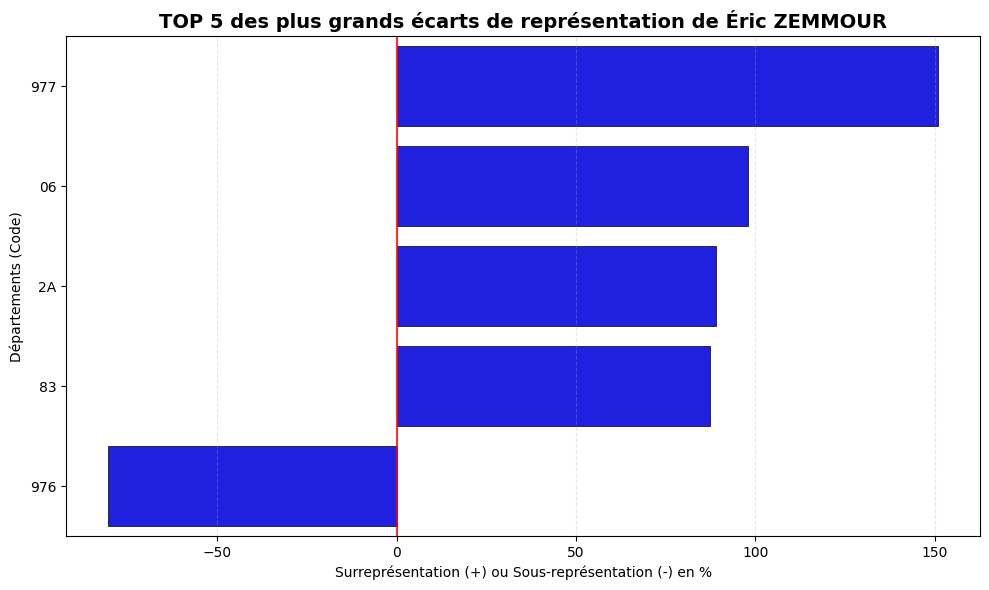

In [76]:
## affichage pour Eric Zemmour
plot_top_surrepresentations(data=score_departements, candidat='Éric ZEMMOUR', nb_dep=5)

## affichage pour Emmannuel Macron
##plot_top_surrepresentations(data=score_departements, candidat='Emmanuel MACRON', nb_dep=5)

# 3. Un peu de cartographie